In [142]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# TASK 1: Exploratory Data Analysis

In [2]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

In [3]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration",
           "num-of-doors","body-style","drive-wheels","engine-location",
           "wheel-base","length","width","height","curb-weight",
           "engine-type","num-of-cylinders","engine-size","fuel-system",
           "bore","stroke","compression-ratio","horsepower",
           "peak-rpm","city-mpg","highway-mpg","price"]

In [10]:
df = pd.read_csv(path, names=headers)

In [12]:
# Display shape
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(205, 26)


In [16]:
# Display first 10 rows
print("\nFirst 10 Rows:")
df.head(10)


First 10 Rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


# Descriptive Statistics

In [18]:
# Replace ? with NaN
df.replace("?", np.nan, inplace=True)

In [20]:
# Convert columns to numeric
numeric_cols = ["normalized-losses", "bore", "stroke",
                "horsepower", "peak-rpm", "price"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

In [22]:
# Mean
print("\nMean:")
print(df.mean(numeric_only=True))


Mean:
symboling                0.834146
normalized-losses      122.000000
wheel-base              98.756585
length                 174.049268
width                   65.907805
height                  53.724878
curb-weight           2555.565854
engine-size            126.907317
bore                     3.329751
stroke                   3.255423
compression-ratio       10.142537
horsepower             104.256158
peak-rpm              5125.369458
city-mpg                25.219512
highway-mpg             30.751220
price                13207.129353
dtype: float64


In [24]:
# Median
print("\nMedian:")
print(df.median(numeric_only=True))


Median:
symboling                1.00
normalized-losses      115.00
wheel-base              97.00
length                 173.20
width                   65.50
height                  54.10
curb-weight           2414.00
engine-size            120.00
bore                     3.31
stroke                   3.29
compression-ratio        9.00
horsepower              95.00
peak-rpm              5200.00
city-mpg                24.00
highway-mpg             30.00
price                10295.00
dtype: float64


In [26]:
# Standard Deviation
print("\nStandard Deviation:")
print(df.std(numeric_only=True))


Standard Deviation:
symboling               1.245307
normalized-losses      35.442168
wheel-base              6.021776
length                 12.337289
width                   2.145204
height                  2.443522
curb-weight           520.680204
engine-size            41.642693
bore                    0.273539
stroke                  0.316717
compression-ratio       3.972040
horsepower             39.714369
peak-rpm              479.334560
city-mpg                6.542142
highway-mpg             6.886443
price                7947.066342
dtype: float64


# Data types

In [30]:
print("\nData Types:")
print(df.dtypes)


Data Types:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


# Unique Values in Categorical Columns

In [33]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in make:
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

Unique values in fuel-type:
['gas' 'diesel']

Unique values in aspiration:
['std' 'turbo']

Unique values in num-of-doors:
['two' 'four' nan]

Unique values in body-style:
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

Unique values in drive-wheels:
['rwd' 'fwd' '4wd']

Unique values in engine-location:
['front' 'rear']

Unique values in engine-type:
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']

Unique values in num-of-cylinders:
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

Unique values in fuel-system:
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


# Visualizations

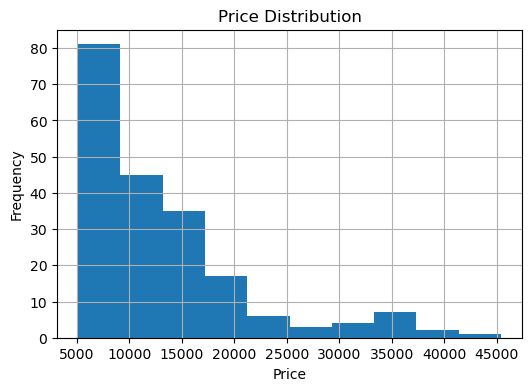

In [36]:
plt.figure(figsize=(6,4))
df['price'].dropna().astype(float).hist()
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

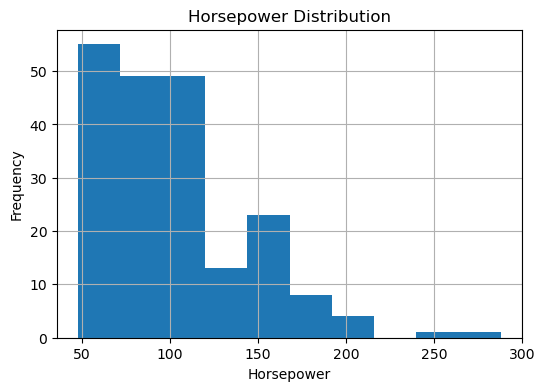

In [38]:
plt.figure(figsize=(6,4))
df['horsepower'].dropna().astype(float).hist()
plt.title("Horsepower Distribution")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.show()

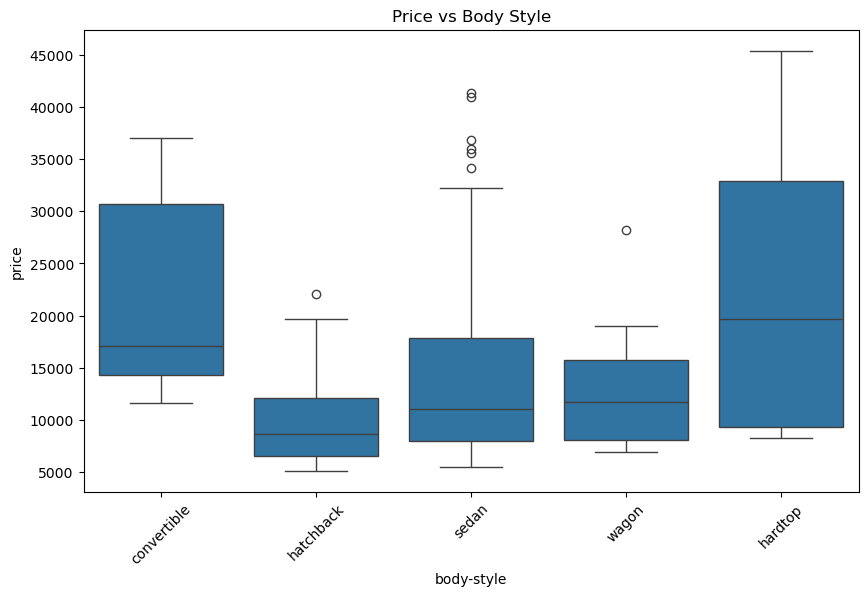

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(x='body-style', y='price', data=df)
plt.title("Price vs Body Style")
plt.xticks(rotation=45)
plt.show()

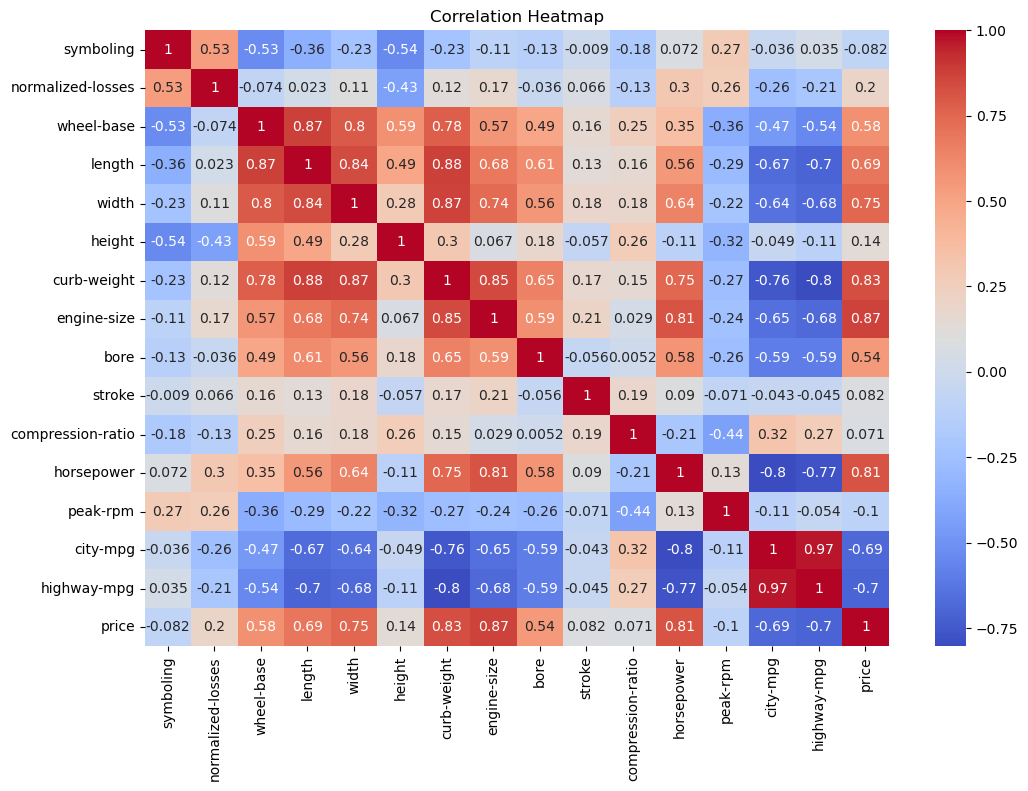

In [42]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Critical Thinking Questions:

• What features seem most related to price?

• Are there any unusual patterns or outliers?

• Does higher horsepower always mean higher price?

### Vehicle Price Drivers and Feature Correlation

When analyzing what drives automobile pricing, the strongest indicators are rooted in a vehicle’s physical dimensions and performance capabilities. Based on statistical correlation, engine size stands out as the most powerful positive predictor of price, meaning that larger engines consistently command higher market values. This is closely followed by the vehicle's curb weight and its horsepower, both of which show a remarkably strong positive relationship with price. Essentially, heavier, high-performance cars require a premium budget. Additionally, structural dimensions like the width and length of the vehicle scale upward alongside the price tag. On the end of the spectrum, fuel efficiency metrics—specifically highway and city miles per gallon (MPG)—exhibit a sharp inverse relationship with cost. Highly fuel-efficient cars are generally priced lower as practical economy vehicles, whereas expensive luxury models or high-power sports cars consume more fuel, driving down their MPG ratings while driving up their price.



### Identifying Structural Anomalies and Data Outliers

A deeper look into the data structures reveals several unique distribution patterns and anomalies that deviate from standard averages. For example, when isolating vehicle prices by body style, sedans display a highly localized median price of around $\$11,000$, yet they feature a prominent cluster of extreme, high-priced outliers stretching from $\$34,000$ to well over $\$40,000$. These outliers point to a distinct market segmentation, capturing elite luxury or track-ready sports sedans within an otherwise budget-friendly category. Similarly, the overall distribution of horsepower is heavily skewed to the right. While the vast majority of consumer vehicles operate comfortably between $50$ and $120$ horsepower, a long tail stretches toward the $300$-horsepower mark. This minor, isolated bracket represents the elite performance tier of the dataset. Finally, a notable pattern of multicollinearity exists among the vehicle's physical traits. Length, width, and curb weight are so tightly bound together by high correlation values that treating them as independent variables in a predictive machine learning model would likely distort the analysis, as they essentially reflect the same underlying factor of vehicle scale.



### The Nuanced Relationship Between Power and Value

While a clear correlation of $0.81$ confirms that higher horsepower heavily influences a steeper price tag, engine power alone does not dictate the final cost of a vehicle. The market is far too segmented for a single variable to act as a definitive rule. For instance, specific body styles like convertibles and hardtops sustain much higher median prices across the board due to structural complexity, low production volume, or premium branding. Consequently, an exotic convertible with moderate horsepower can easily cost more than a mainstream sedan equipped with a significantly larger, more powerful engine. Factors such as manufacturing materials, brand prestige, technological features, and targeted consumer demographics create layers of pricing nuance that frequently disrupt the linear relationship between raw engine performance and retail value.

# TASK 2: Data Preprocessing & Feature Engineering

### Missing Values

In [49]:
# Identify missing values
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

# Convert columns to numeric
numeric_cols = ["normalized-losses", "bore", "stroke",
                "horsepower", "peak-rpm", "price"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

Missing Values in Each Column:

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


## Mean Replacement

In [53]:
# Replace missing values with mean
mean_norm_loss = df["normalized-losses"].mean()
df["normalized-losses"].replace(np.nan, mean_norm_loss, inplace=True)

mean_bore = df["bore"].mean()
df["bore"].replace(np.nan, mean_bore, inplace=True)

mean_stroke = df["stroke"].mean()
df["stroke"].replace(np.nan, mean_stroke, inplace=True)

mean_horsepower = df["horsepower"].mean()
df["horsepower"].replace(np.nan, mean_horsepower, inplace=True)

mean_peakrpm = df["peak-rpm"].mean()
df["peak-rpm"].replace(np.nan, mean_peakrpm, inplace=True)

C:\Users\Tanmayee\AppData\Local\Temp\ipykernel_1876\2737708534.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["normalized-losses"].replace(np.nan, mean_norm_loss, inplace=True)
C:\Users\Tanmayee\AppData\Local\Temp\ipykernel_1876\2737708534.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

# Mode Replacement

In [56]:
# Replace missing values in num-of-doors using mode
mode_doors = df["num-of-doors"].mode()[0]
df["num-of-doors"].replace(np.nan, mode_doors, inplace=True)

# Remove rows where price is missing
df.dropna(subset=["price"], axis=0, inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nMissing values after treatment:\n")
print(df.isnull().sum())


Missing values after treatment:

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


C:\Users\Tanmayee\AppData\Local\Temp\ipykernel_1876\2453582295.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["num-of-doors"].replace(np.nan, mode_doors, inplace=True)


## CONVERT DATA TYPES

In [59]:
# Convert price and horsepower to float
df["price"] = df["price"].astype(float)
df["horsepower"] = df["horsepower"].astype(float)

print("\nData Types After Conversion:\n")
print(df[["price", "horsepower"]].dtypes)


Data Types After Conversion:

price         float64
horsepower    float64
dtype: object


## FEATURE ENGINEERING

In [62]:
# Create city-L/100km column
df["city-L/100km"] = 235 / df["city-mpg"]

print("\nNew Feature Created:")
print(df[["city-mpg", "city-L/100km"]].head())


New Feature Created:
   city-mpg  city-L/100km
0        21     11.190476
1        21     11.190476
2        19     12.368421
3        24      9.791667
4        18     13.055556


# BINNING

In [67]:
# Create bins for horsepower
bins = np.linspace(min(df["horsepower"]),
                   max(df["horsepower"]), 4)

group_names = ['Low', 'Medium', 'High']

df['horsepower-binned'] = pd.cut(df['horsepower'],
                                 bins,
                                 labels=group_names,
                                 include_lowest=True)

print("\nHorsepower Bins:")
print(df[['horsepower', 'horsepower-binned']].head(10))


Horsepower Bins:
   horsepower horsepower-binned
0       111.0               Low
1       111.0               Low
2       154.0            Medium
3       102.0               Low
4       115.0               Low
5       110.0               Low
6       110.0               Low
7       110.0               Low
8       140.0            Medium
9       101.0               Low


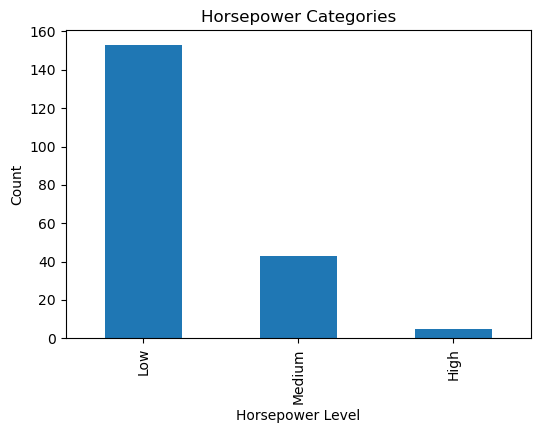

In [69]:
# Visualize bins
plt.figure(figsize=(6,4))
df["horsepower-binned"].value_counts().plot(kind='bar')

plt.title("Horsepower Categories")
plt.xlabel("Horsepower Level")
plt.ylabel("Count")
plt.show()

# NORMALIZATION

In [72]:
# Normalize length column
df["length-normalized"] = df["length"] / df["length"].max()

print("\nNormalized Feature:")
print(df[["length", "length-normalized"]].head())


Normalized Feature:
   length  length-normalized
0   168.8           0.811148
1   168.8           0.811148
2   171.2           0.822681
3   176.6           0.848630
4   176.6           0.848630


In [74]:
print("\nFinal Dataset Preview:")
df.head()


Final Dataset Preview:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,length-normalized
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,Low,0.811148
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,Low,0.811148
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0.822681
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,Low,0.848630
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,Low,0.848630


# TASK 3: Model Development (Regression)

In [79]:
# Independent variables (features)
X = df[["horsepower", "engine-size"]]

# Dependent variable (target)
y = df["price"]

In [81]:
# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (160, 2)
Testing set shape: (41, 2)


## Part A

In [83]:
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [85]:
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)


Intercept:
-6389.379095856182

Coefficients:
[ 50.02562    111.19279404]


In [87]:
y_pred = model.predict(X_test)

In [89]:
# R2 Score
r2 = r2_score(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

In [91]:
print("\nModel Evaluation Results")

print("\nR2 Score:")
print(r2)

print("\nMean Absolute Error (MAE):")
print(mae)

print("\nMean Squared Error (MSE):")
print(mse)


Model Evaluation Results

R2 Score:
0.7555654387380518

Mean Absolute Error (MAE):
3997.041824898604

Mean Squared Error (MSE):
29905779.800282188


In [93]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
results.head(10)


Actual vs Predicted Prices:


,Actual Price,Predicted Price
95,8249.0,7848.089706
15,41315.0,25954.577699
30,6855.0,7642.305076
158,9258.0,8009.308120
128,11850.0,12567.767183
115,5572.0,7019.714528
69,35056.0,27383.705810
171,9988.0,11778.498817
175,15998.0,20678.713505
45,35550.0,31102.870887


## Part B

In [100]:
# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [102]:
rf_predictions = rf_model.predict(X_test)

In [104]:
# R2 Score
rf_r2 = r2_score(y_test, rf_predictions)

# Mean Absolute Error
rf_mae = mean_absolute_error(y_test, rf_predictions)

# Mean Squared Error
rf_mse = mean_squared_error(y_test, rf_predictions)

In [106]:
print("RANDOM FOREST REGRESSOR RESULTS")

print("\nR2 Score:")
print(rf_r2)

print("\nMean Absolute Error (MAE):")
print(rf_mae)

print("\nMean Squared Error (MSE):")
print(rf_mse)

RANDOM FOREST REGRESSOR RESULTS

R2 Score:
0.9268293080707919

Mean Absolute Error (MAE):
2153.8512526504664

Mean Squared Error (MSE):
8952198.041766157


In [108]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    
    'R2 Score': [r2, rf_r2],
    
    'MAE': [mae, rf_mae],
    
    'MSE': [mse, rf_mse]
})


In [110]:
print("MODEL COMPARISON")

print(comparison)

MODEL COMPARISON
                     Model  R2 Score          MAE           MSE
0        Linear Regression  0.755565  3997.041825  2.990578e+07
1  Random Forest Regressor  0.926829  2153.851253  8.952198e+06


In [112]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
       Feature  Importance
1  engine-size    0.763324
0   horsepower    0.236676


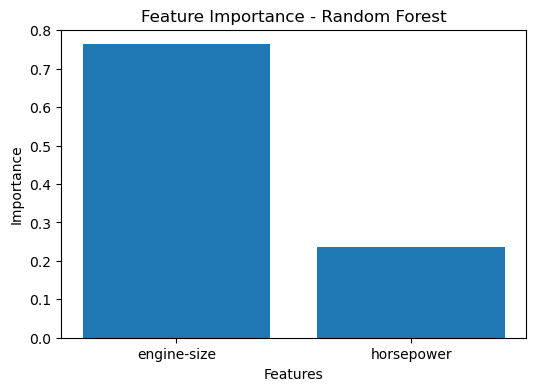

In [114]:
plt.figure(figsize=(6,4))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

# PART C: EXPERIMENTATION

In [119]:
# 70/30 TRAIN-TEST SPLIT

# Split dataset
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Shape:", X_train_70.shape)
print("Testing Shape:", X_test_30.shape)

Training Shape: (140, 2)
Testing Shape: (61, 2)


## LINEAR REGRESSION MODEL

In [122]:
lr_model_70 = LinearRegression()

# Train model
lr_model_70.fit(X_train_70, y_train_70)

# Predict
lr_predictions_70 = lr_model_70.predict(X_test_30)

# Evaluation
lr_r2_70 = r2_score(y_test_30, lr_predictions_70)

lr_mae_70 = mean_absolute_error(
    y_test_30,
    lr_predictions_70
)

lr_mse_70 = mean_squared_error(
    y_test_30,
    lr_predictions_70
)

## RANDOM FOREST MODEL

In [125]:
rf_model_70 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model_70.fit(X_train_70, y_train_70)

# Predict
rf_predictions_70 = rf_model_70.predict(X_test_30)

# Evaluation
rf_r2_70 = r2_score(y_test_30, rf_predictions_70)

rf_mae_70 = mean_absolute_error(
    y_test_30,
    rf_predictions_70
)

rf_mse_70 = mean_squared_error(
    y_test_30,
    rf_predictions_70
)

In [127]:
# COMPARE ALL RESULTS

comparison_results = pd.DataFrame({

    'Model': [
        'Linear Regression (80/20)',
        'Random Forest (80/20)',
        'Linear Regression (70/30)',
        'Random Forest (70/30)'
    ],

    'R2 Score': [
        r2,
        rf_r2,
        lr_r2_70,
        rf_r2_70
    ],

    'MAE': [
        mae,
        rf_mae,
        lr_mae_70,
        rf_mae_70
    ],

    'MSE': [
        mse,
        rf_mse,
        lr_mse_70,
        rf_mse_70
    ]
})


print("MODEL PERFORMANCE COMPARISON")

comparison_results

MODEL PERFORMANCE COMPARISON


,Model,R2 Score,MAE,MSE
0,Linear Regression (80/20),0.755565,3997.041825,2.990578e+07
1,Random Forest (80/20),0.926829,2153.851253,8.952198e+06
2,Linear Regression (70/30),0.764221,3359.327961,2.234990e+07
3,Random Forest (70/30),0.905406,2099.282311,8.966677e+06


In [129]:
# IDENTIFY BEST MODEL

best_model = comparison_results.sort_values(
    by='R2 Score',
    ascending=False
)

print("BEST MODEL")

best_model.head(1)

BEST MODEL


,Model,R2 Score,MAE,MSE
1,Random Forest (80/20),0.926829,2153.851253,8.952198e+06


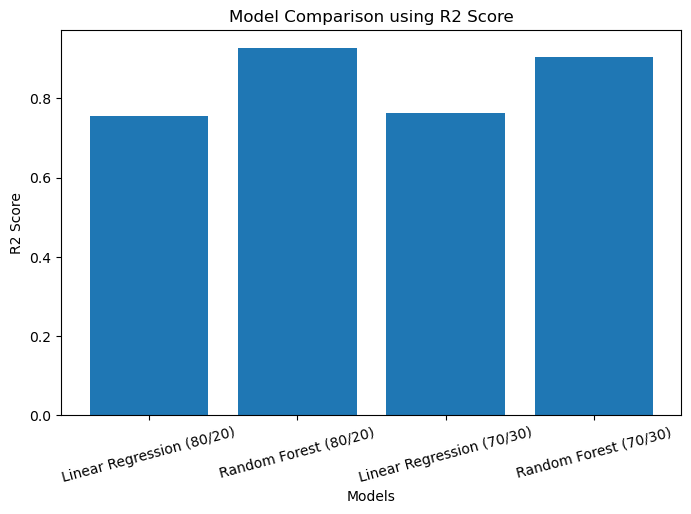

In [131]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_results['Model'],
    comparison_results['R2 Score']
)

plt.title("Model Comparison using R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.show()

# TASK 4: CLASSIFICATION MODEL

In [134]:
# Convert price into categories
df['price-category'] = pd.qcut(
    df['price'],
    3,
    labels=['Low', 'Medium', 'High']
)

print("\nPrice Categories:")
print(df['price-category'].value_counts())


Price Categories:
price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64


In [136]:
# Independent variables
X = df[['horsepower', 'engine-size', 'curb-weight']]

# Target variable
y = df['price-category']


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [144]:
# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [148]:
y_pred = log_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("MODEL ACCURACY")

print("Accuracy Score:", accuracy)

MODEL ACCURACY
Accuracy Score: 0.7804878048780488


In [150]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)


print("CONFUSION MATRIX")


print(cm)

# CLASSIFICATION REPORT

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))


CONFUSION MATRIX
[[12  0  2]
 [ 0 12  2]
 [ 2  3  8]]
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.86      0.86      0.86        14
         Low       0.80      0.86      0.83        14
      Medium       0.67      0.62      0.64        13

    accuracy                           0.78        41
   macro avg       0.77      0.78      0.77        41
weighted avg       0.78      0.78      0.78        41



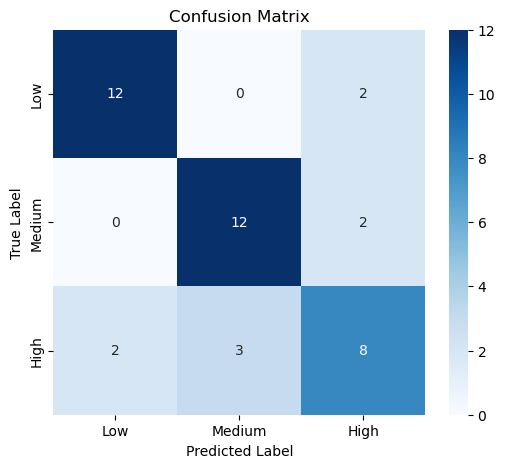

In [152]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [154]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(results.head(10))


Actual vs Predicted:
     Actual Predicted
95      Low       Low
15     High      High
30      Low       Low
158  Medium       Low
128  Medium    Medium
115     Low       Low
69     High      High
171  Medium    Medium
175    High      High
45     High      High


# TASK 5: MODEL EVALUATION & VISUALIZATION

In [157]:
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison_df.head(10))


  Actual Price Predicted Price
0          Low             Low
1         High            High
2          Low             Low
3       Medium             Low
4       Medium          Medium
5          Low             Low
6         High            High
7       Medium          Medium
8         High            High
9         High            High


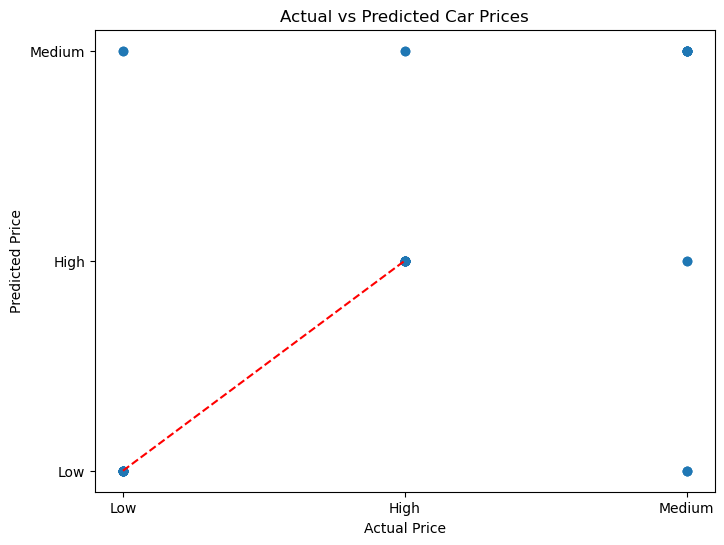

In [159]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted Car Prices")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

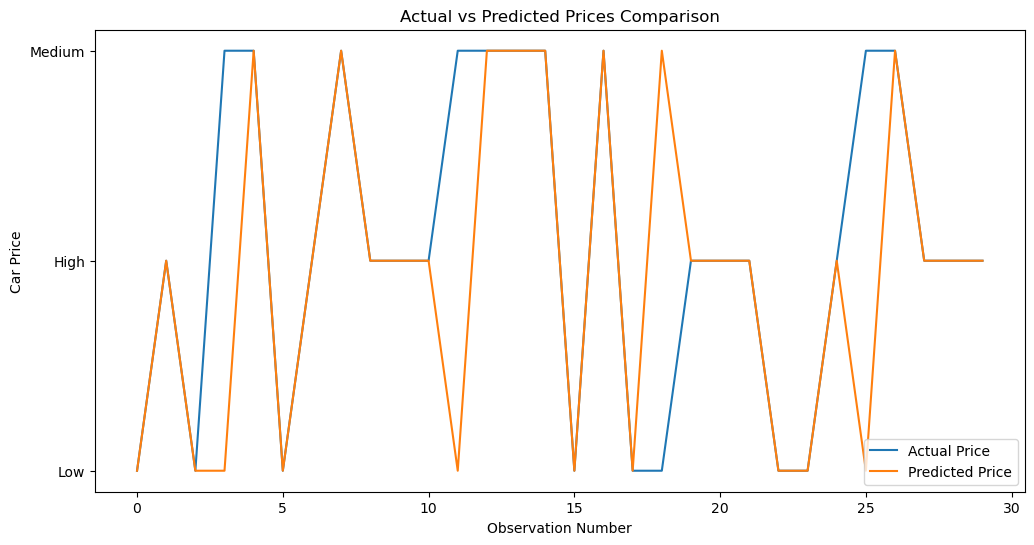

In [161]:
plt.figure(figsize=(12,6))

# Reset index for proper plotting
comparison_df = comparison_df.reset_index(drop=True)

plt.plot(
    comparison_df['Actual Price'][:30],
    label='Actual Price'
)

plt.plot(
    comparison_df['Predicted Price'][:30],
    label='Predicted Price'
)

plt.title("Actual vs Predicted Prices Comparison")

plt.xlabel("Observation Number")
plt.ylabel("Car Price")

plt.legend()

plt.show()